In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

result=pd.read_csv("Results.csv", header=None)

equipDB = pd.read_csv("EquipDB.csv", header=None, names=["ID_equipamento", "TempoAposFalha", "Cluster", "CustoDeFalha"])
ClusterDB= pd.read_csv("ClusterDB.csv", header=None, names=["ID_Cluster", "eta", "beta"])
MPDB=pd.read_csv("MPDB.csv", header=None, names=["ID_plano_risco", "Fator_risco(k)", "CustoDoPlano"])

# Unir informações do ClusterDB ao equipDB
equipDB = equipDB.merge(ClusterDB, left_on="Cluster", right_on="ID_Cluster")

def Fi(t, eta, beta):
    return 1-np.exp(-(t/eta)**beta)

def P(t0, eta, beta, k, delta_t):
    return (Fi((t0+k*delta_t), eta=eta, beta=beta)-Fi(t=t0, eta=eta, beta=beta))/(1-Fi(t=t0, eta=eta, beta=beta))

# Criar a matriz  de probabilidade Pij
Pij = np.zeros((len(equipDB), len(MPDB)))
delta_t = 5  # Definir um valor para Delta_t,

for i, equipamento in equipDB.iterrows():
    t0 = equipamento["TempoAposFalha"]
    eta = equipamento["eta"]
    beta = equipamento["beta"]
    
    for j, plano in MPDB.iterrows():
        k = plano["Fator_risco(k)"]
        Pij[i, j] = P(t0, eta, beta, k, delta_t)

In [2]:
equipDB

,ID_equipamento,TempoAposFalha,Cluster,CustoDeFalha,ID_Cluster,eta,beta
0,1,2,1,5,1,8,1.0
1,2,1,2,10,2,11,1.1
2,3,9,2,9,2,11,1.1
3,4,3,1,3,1,8,1.0
4,5,4,4,6,4,16,1.5
...,...,...,...,...,...,...,...
495,496,1,2,9,2,11,1.1
496,497,3,2,8,2,11,1.1
497,498,2,2,2,2,11,1.1
498,499,32,2,7,2,11,1.1


In [7]:
from scipy.stats import entropy
from scipy.special import gamma

def f1(X, equipDB, MPDB, Pij):
    """
    Calcula o custo total de manutenção.

    Parâmetros:
    - x: matriz numpy (n x 3) representando as variáveis de decisão x_{i,j}
    - m: vetor numpy (3,) representando os custos de manutenção m_j para cada coluna

    Retorna:
    - Custo total de manutenção (float)
    """
    return sum(MPDB.iloc[p - 1]["CustoDoPlano"] for p in X)

def f2(X, equipDB, MPDB, Pij):
    """
    Calcula o custo esperado de falha.

    Parâmetros:
    - x: matriz numpy (n x 3) representando as variáveis de decisão x_{i,j}
    - p: matriz numpy (n x 3) representando as probabilidades de falha p_{i,j}
    - f: vetor numpy (n,) representando os custos de falha f_i

    Retorna:
    - Custo esperado de falha (float)
    """
    return sum(
        Pij[i, X[i] - 1] * equipDB.loc[i, "CustoDeFalha"]
        for i in range(len(X))
    )

def f3(X,equipDB):
    # Conta quantas vezes o valor 3 aparece
    sum_t=np.zeros(3)
    for v, eta,beta in zip(X, equipDB["eta"], equipDB["beta"]):
        sum_t[v-1] += eta * gamma(1 + 1/beta)
    return np.std(sum_t)  # Se não houver o valor 3


def f4(result, equipDB):
    # Cria um DataFrame combinando cluster e manutenção
    df = pd.DataFrame({
        'ID_Cluster': equipDB["ID_Cluster"],
        'Tipo_Manutencao': result
    })

    # Tabela cruzada: linhas = clusters, colunas = tipos de manutenção
    tabela = pd.crosstab(df['ID_Cluster'], df['Tipo_Manutencao'])

    # Cálculo da entropia por cluster (medida de balanceamento)
    def entropia_cluster(row):
        p = row / row.sum()
        return entropy(p, base=2)

    entropias = tabela.apply(entropia_cluster, axis=1)

    return entropias.mean()


# Lista para armazenar os resultados
data = []

# Itera sobre cada item em 'results'
for i in range(result.shape[0]):
    row = {
        
        'f1': f1(result.iloc[i], equipDB, MPDB, Pij),
        'f2': f2(result.iloc[i], equipDB, MPDB, Pij),
        'f3': f3(result.iloc[i],equipDB),
        'f4': f4(result.iloc[i],equipDB)
    }
    data.append(row)

# Cria o DataFrame
df = pd.DataFrame(data)

print(df)

       f1           f2           f3        f4
0   505.0  1264.943392  1191.185958  1.174270
1    41.0  1711.070070  2376.113243  0.414190
2   616.0  1193.295498  1299.127722  1.144065
3    46.0  1697.544461  2373.293249  0.419417
4    29.0  1722.168356  2419.116446  0.298114
5   947.0  1064.330488  2367.682632  0.451623
6   430.0  1318.717208  1252.014532  1.126860
7   924.0  1070.735959  2235.502722  0.594210
8    30.0  1717.386025  2479.949436  0.309646
9   926.0  1070.041439  2226.807789  0.600064
10  926.0  1070.024787  2239.957427  0.585112
11  962.0  1063.494528  2366.194433  0.372512
12  921.0  1069.407542  2248.433287  0.573193
13  634.0  1181.308707  1362.780684  1.098290
14  414.0  1330.249145  1270.021261  1.144219
15  910.0  1069.910864  2225.056564  0.595886
16   46.0  1699.260485  2375.426002  0.425284
17  963.0  1060.852359  2404.138336  0.364497
18  928.0  1069.715365  2268.018622  0.565505
19  963.0  1061.057632  2405.570221  0.378871
20  975.0  1058.325404  2490.90150

Ranking (melhor para pior):
1º lugar: A27 (fluxo líquido = 0.2282)
2º lugar: A30 (fluxo líquido = 0.2205)
3º lugar: A29 (fluxo líquido = 0.2103)
4º lugar: A1 (fluxo líquido = 0.1949)
5º lugar: A16 (fluxo líquido = 0.1667)
6º lugar: A31 (fluxo líquido = 0.1615)
7º lugar: A15 (fluxo líquido = 0.1590)
8º lugar: A3 (fluxo líquido = 0.1564)
9º lugar: A7 (fluxo líquido = 0.1513)
10º lugar: A13 (fluxo líquido = 0.1462)
11º lugar: A14 (fluxo líquido = 0.1333)
12º lugar: A37 (fluxo líquido = 0.1154)
13º lugar: A32 (fluxo líquido = 0.1026)
14º lugar: A26 (fluxo líquido = 0.0744)
15º lugar: A6 (fluxo líquido = 0.0718)
16º lugar: A10 (fluxo líquido = 0.0654)
17º lugar: A11 (fluxo líquido = 0.0526)
18º lugar: A8 (fluxo líquido = 0.0513)
19º lugar: A19 (fluxo líquido = 0.0410)
20º lugar: A34 (fluxo líquido = -0.0179)
21º lugar: A24 (fluxo líquido = -0.0205)
22º lugar: A18 (fluxo líquido = -0.0256)
23º lugar: A20 (fluxo líquido = -0.0282)
24º lugar: A23 (fluxo líquido = -0.0308)
25º lugar: A28 (fluxo

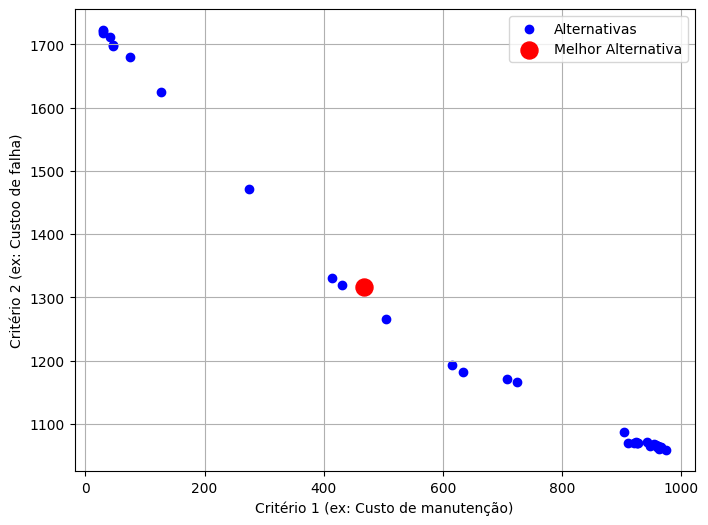

f1     467.000000
f2    1316.747135
f3     813.394617
f4       1.425849
Name: 26, dtype: float64

In [10]:
pareto=df.values

def normalize(X, maximize):
    X_norm = np.zeros_like(X, dtype=float)
    for j in range(X.shape[1]):
        col = X[:, j]
        min_val = np.min(col)
        max_val = np.max(col)
        if max_val - min_val == 0:
            X_norm[:, j] = 0.5
        elif maximize[j]:
            X_norm[:, j] = (col - min_val) / (max_val - min_val)
        else:
            X_norm[:, j] = (max_val - col) / (max_val - min_val)
    return X_norm

def preference_function(d):
    return 0 if d <= 0 else 1

def preference_matrix(X_norm, weights):
    n, m = X_norm.shape
    P = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i != j:
                soma = 0
                for c in range(m):
                    d = X_norm[i, c] - X_norm[j, c]
                    p = preference_function(d)
                    soma += weights[c] * p
                P[i, j] = soma
    return P

def calculate_flows(P):
    n = P.shape[0]
    phi_plus = np.sum(P, axis=1) / (n - 1)
    phi_minus = np.sum(P, axis=0) / (n - 1)
    phi_liquido = phi_plus - phi_minus
    return phi_plus, phi_minus, phi_liquido

def promethee_ii(X, weights, maximize):
    X_norm = normalize(X, maximize)
    P = preference_matrix(X_norm, weights)
    phi_plus, phi_minus, phi_liquido = calculate_flows(P)
    ranking = np.argsort(-phi_liquido)
    return ranking, phi_liquido, P

# Exemplo com seus dados

weights = np.array([0.35, 0.40,0.10,0.15])
maximize = np.array([False, False, False, True])

ranking, phi_liquido, P = promethee_ii(pareto, weights, maximize)

print("Ranking (melhor para pior):")
for pos, alt in enumerate(ranking):
    print(f"{pos+1}º lugar: A{alt+1} (fluxo líquido = {phi_liquido[alt]:.4f})")

# --- Gráfico das duas primeiras colunas ---

plt.figure(figsize=(8,6))

# Plota todas as alternativas
plt.scatter(pareto[:, 0], pareto[:, 1], c='blue', label='Alternativas')

# Destaca a melhor alternativa em vermelho
melhor = ranking[0]
plt.scatter(pareto[melhor, 0], pareto[melhor, 1], c='red', s=150, label='Melhor Alternativa')

plt.xlabel('Critério 1 (ex: Custo de manutenção)')
plt.ylabel('Critério 2 (ex: Custoo de falha)')
# plt.title('PROMETHEE II - Melhores alternativas (duas primeiras colunas)')
plt.legend()
plt.grid(True)
plt.show()

df.iloc[ranking[0]]


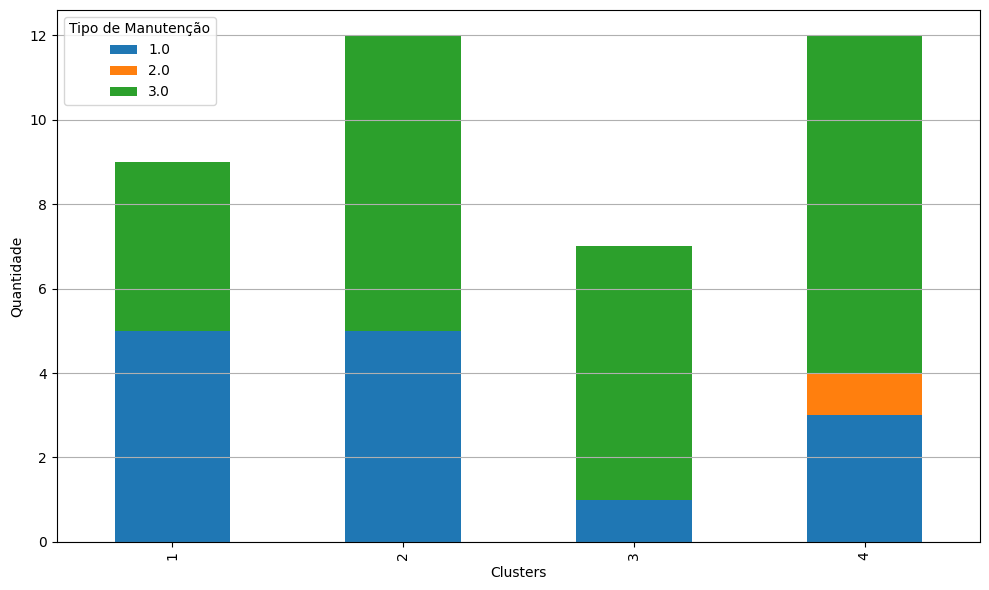

In [5]:
df = pd.DataFrame({
        'ID_Cluster': equipDB["ID_Cluster"],
        'Tipo_Manutencao': result[ranking[0]]
    })

    # Tabela cruzada: linhas = clusters, colunas = tipos de manutenção
tabela = pd.crosstab(df['ID_Cluster'], df['Tipo_Manutencao'])

# Plotando distribuição por cluster
tabela.plot(kind='bar', stacked=True, figsize=(10, 6))
# plt.title("Distribuição de Tipos de Manutenção por Cluster")
plt.xlabel("Clusters")
plt.ylabel("Quantidade")
plt.legend(title="Tipo de Manutenção")
plt.grid(axis='y')
plt.tight_layout()
plt.show()